# 2. Feature Engineering & Augmentation

Aligned with ETASR 2026 (Zennou et al.). Features: 40 dimensions (13 MFCCs + Deltas + RMSE). Augmentations: Noise, Time Stretch, Pitch Shift.

All extraction and augmentation logic is defined natively here to serve as the foundation for the `src` folder scripts.

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IPython.display as ipd
import random

# Constants
TARGET_SR    = 22050
DURATION     = 3.0                     
N_SAMPLES    = int(TARGET_SR * DURATION)
FRAME_LENGTH = int(0.025 * TARGET_SR)  
HOP_LENGTH   = int(0.010 * TARGET_SR)  
N_FFT        = 2048                    
N_MFCC       = 13                      
MAX_FRAMES   = 400                     
N_FEATURES   = N_MFCC * 3 + 1    




## Feature Extraction Functions

In [2]:
def preprocess_audio(file_path: str) -> np.ndarray:
    """Load, resample, pre-emphasise, trim silence, and fix length."""
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # 1. Resample to TARGET_SR
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)

    # 2. Pre-emphasis filter
    y = librosa.effects.preemphasis(y, coef=0.97)

    # 3. Trim leading/trailing silence
    y, _ = librosa.effects.trim(y, top_db=30)

    # 4. Pad or truncate to fixed duration
    if len(y) > N_SAMPLES:
        y = y[:N_SAMPLES]
    else:
        y = np.pad(y, (0, N_SAMPLES - len(y)), mode="constant")

    return y


def extract_features(y: np.ndarray, sr: int = TARGET_SR) -> np.ndarray:
    """
    Extract MFCC + Delta + Delta-Delta + RMSE features.

    Returns
    -------
    np.ndarray of shape (MAX_FRAMES, N_FEATURES)
        N_FEATURES = 13+13+13+1 = 40
    """
    # 1. MFCC (13 coefficients)
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=FRAME_LENGTH,
    )  # shape: (13, T)

    # 2. Delta MFCC
    delta = librosa.feature.delta(mfcc, width=9)       # (13, T)

    # 3. Delta-Delta MFCC
    delta2 = librosa.feature.delta(mfcc, order=2, width=9)  # (13, T)

    # 4. RMSE (root mean square energy) per frame
    rmse = librosa.feature.rms(
        y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH
    )  # shape: (1, T_rmse)  — may differ by ±1 frame from MFCC

    # Align RMSE length to MFCC frame count
    T_mfcc = mfcc.shape[1]
    if rmse.shape[1] > T_mfcc:
        rmse = rmse[:, :T_mfcc]
    elif rmse.shape[1] < T_mfcc:
        rmse = np.pad(rmse, ((0, 0), (0, T_mfcc - rmse.shape[1])), mode="edge")

    # Concatenate → (40, T)
    features = np.concatenate([mfcc, delta, delta2, rmse], axis=0)

    # Transpose → (T, 40)
    features = features.T

    # Zero-pad or truncate to MAX_FRAMES (400)
    T = features.shape[0]
    if T >= MAX_FRAMES:
        features = features[:MAX_FRAMES, :]
    else:
        pad = np.zeros((MAX_FRAMES - T, N_FEATURES), dtype=np.float32)
        features = np.vstack([features, pad])

    return features.astype(np.float32)   # (400, 40)


## Data Augmentation Functions

In [3]:
def add_noise(y: np.ndarray, snr_db: float = 20.0) -> np.ndarray:
    """Add Gaussian noise at a given SNR (dB)."""
    signal_power = np.mean(y ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), size=y.shape)
    return (y + noise).astype(np.float32)


def time_stretch(y: np.ndarray,
                 rate_min: float = 0.8,
                 rate_max: float = 1.2) -> np.ndarray:
    """Randomly stretch / compress the time axis without affecting pitch."""
    rate = np.random.uniform(rate_min, rate_max)
    return librosa.effects.time_stretch(y.astype(np.float32), rate=rate)


def time_shift(y: np.ndarray, sr: int = 22050,
               shift_max: float = 0.5) -> np.ndarray:
    """Randomly shift the signal left or right by up to shift_max seconds."""
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(y, shift).astype(np.float32)


def pitch_shift(y: np.ndarray, sr: int = 22050,
                semitones_max: float = 2.0) -> np.ndarray:
    """Randomly shift pitch by ±semitones_max semitones."""
    n_steps = np.random.uniform(-semitones_max, semitones_max)
    return librosa.effects.pitch_shift(
        y.astype(np.float32), sr=sr, n_steps=n_steps
    )


# ── Augmentation strategy ─────────────────────────────────────────────────────

# Each entry: (function, kwargs, probability)
AUGMENTATIONS = [
    (add_noise,    {"snr_db": 20.0},                          0.5),
    (time_stretch, {"rate_min": 0.85, "rate_max": 1.15},      0.4),
    (time_shift,   {"sr": 22050, "shift_max": 0.3},           0.4),
    (pitch_shift,  {"sr": 22050, "semitones_max": 2.0},       0.3),
]

def augment(y: np.ndarray, sr: int = 22050,
            p_apply: float = 1.0) -> np.ndarray:
    """
    Apply a random subset of augmentations to an audio array.

    Parameters
    ----------
    y        : Raw audio signal (float32 array)
    sr       : Sample rate (default 22050)
    p_apply  : Overall probability of applying any augmentation at all.
               Set to 1.0 to always augment (typical for training).

    Returns
    -------
    Augmented audio signal (same dtype as input, length may vary slightly).
    """
    if np.random.random() > p_apply:
        return y

    y_aug = y.copy()
    for fn, kwargs, prob in AUGMENTATIONS:
        if np.random.random() < prob:
            try:
                y_aug = fn(y_aug, **kwargs)
            except Exception:
                # Fallback: skip this augmentation if it fails
                pass

    return y_aug.astype(np.float32)


## Feature Extraction (40-Dim)

/Users/wandika/dibimbing/Final Project/venv-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracted feature shape: (400, 40) (Expected: 400, 40)


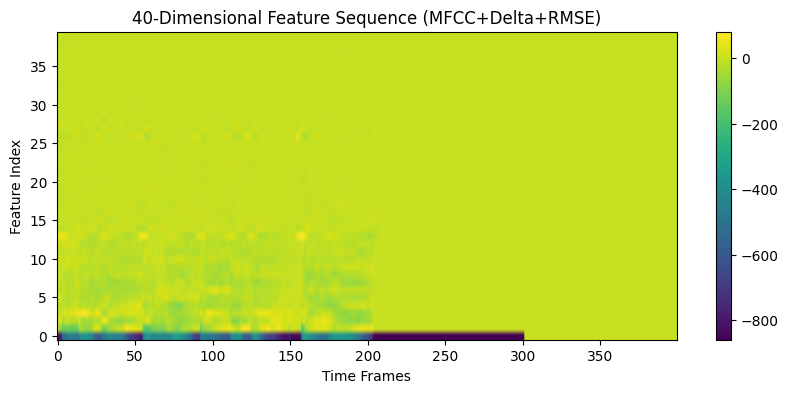

In [4]:
df = pd.read_csv('../data/processed/manifest.csv')
sample_file = df['file_path'].iloc[0]
y = preprocess_audio(sample_file)

features = extract_features(y)
print(f"Extracted feature shape: {features.shape} (Expected: 400, 40)")

plt.figure(figsize=(10, 4))
plt.imshow(features.T, aspect='auto', origin='lower', cmap='viridis')
plt.title("40-Dimensional Feature Sequence (MFCC+Delta+RMSE)")
plt.ylabel("Feature Index")
plt.xlabel("Time Frames")
plt.colorbar()
plt.show()

## Data Augmentation Examples

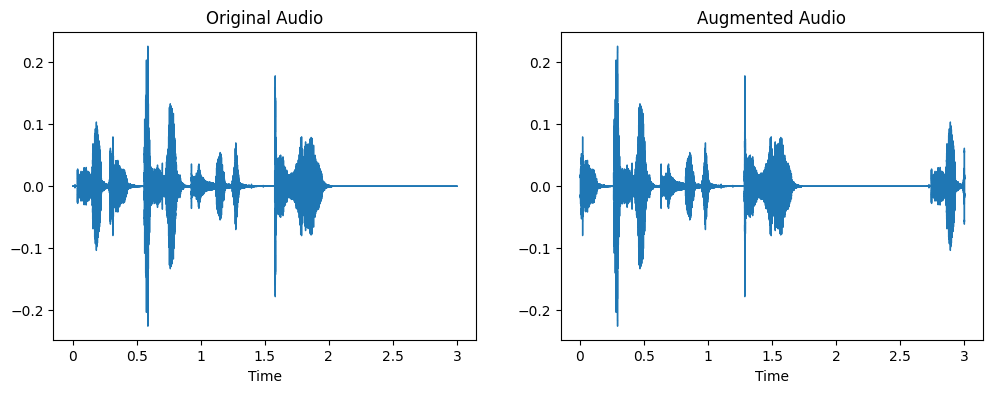

Original:


Augmented:


In [5]:
y_aug = augment(y)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=TARGET_SR)
plt.title("Original Audio")
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_aug, sr=TARGET_SR)
plt.title("Augmented Audio")
plt.show()

print("Original:")
display(ipd.Audio(y, rate=TARGET_SR))
print("Augmented:")
display(ipd.Audio(y_aug, rate=TARGET_SR))